
# Twiga Logistics Optimization - Data Discovery & Territory Analytics

This notebook performs:

1. Data loading and validation
2. Relationship mapping (Depot → Route → Shop → Order)
3. Zone polygon analysis
4. Unzoned shop detection
5. Overlap detection
6. Depot demand analysis
7. Truck utilization analysis
8. Foundation for dynamic depot optimization


In [ ]:

import pandas as pd
import geopandas as gpd
import json
from shapely.geometry import Point, shape
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Data

In [5]:

orders = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Twiga Data Science/twiga_routing_model/orders.csv')
shops = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Twiga Data Science/twiga_routing_model/shops.csv')
zones = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Twiga Data Science/twiga_routing_model/zones.csv')
depots = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Twiga Data Science/twiga_routing_model/depots-master.csv')
routes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Twiga Data Science/twiga_routing_model/routes.csv')
vehicles = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Twiga Data Science/twiga_routing_model/trucks-vehicles.csv')
dispatch = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Twiga Data Science/twiga_routing_model/dispatch-jan-april.csv')

datasets = {
    'orders': orders,
    'shops': shops,
    'zones': zones,
    'depots': depots,
    'routes': routes,
    'vehicles': vehicles,
    'dispatch': dispatch
}

for name, df in datasets.items():
    print(f'\n{name.upper()}')
    print(df.shape)
    print(df.columns.tolist())



ORDERS
(12124, 10)
['delivery_date', 'order_id', 'order_date', 'shop_id', 'route_plan_id', 'depot_id', 'route_id', 'order_status', 'amount', 'weight']

SHOPS
(7481, 6)
['shop_id', 'shop_name', 'latitude', 'longitude', 'route_id', 'date_created']

ZONES
(101, 7)
['zone_id', 'area_id', 'name', 'zone_status', 'geographic_bounds', 'outlets', 'setting']

DEPOTS
(41, 4)
['depot_id', 'depot_name', 'latitude', 'longitude']

ROUTES
(309, 3)
['route_id', 'route_name', 'depot_id']

VEHICLES
(944, 6)
['vehicle_id', 'registration_number', 'load_capacity', 'route_id', 'active', 'depot_id']

DISPATCH
(123357, 6)
['delivery_date', 'vehicle_registration_number', 'product_name', 'product_item_name', 'quantity', 'weight']


## Data Quality Checks

In [6]:

for name, df in datasets.items():
    print('\n', name)
    print(df.isnull().sum().sort_values(ascending=False).head(10))



 orders
route_plan_id    131
order_date         1
route_id           1
order_status       1
shop_id            1
depot_id           1
amount             1
weight             1
order_id           0
delivery_date      0
dtype: int64

 shops
route_id        82
shop_name        5
date_created     1
longitude        1
shop_id          0
latitude         0
dtype: int64

 zones
area_id              91
zone_id               0
name                  0
zone_status           0
geographic_bounds     0
outlets               0
setting               0
dtype: int64

 depots
longitude     13
latitude      13
depot_name     0
depot_id       0
dtype: int64

 routes
route_name    1
route_id      0
depot_id      0
dtype: int64

 vehicles
route_id               163
depot_id               159
registration_number      0
vehicle_id               0
load_capacity            0
active                   0
dtype: int64

 dispatch
quantity                       1
product_item_name              1
weight               

## Create Zone GeoDataFrame

In [7]:

def parse_polygon(x):
    try:
        return shape(json.loads(x))
    except:
        return None

zones['geometry'] = zones['geographic_bounds'].apply(parse_polygon)

zone_gdf = gpd.GeoDataFrame(
    zones,
    geometry='geometry',
    crs='EPSG:4326'
)

zone_gdf.head()


,zone_id,area_id,name,zone_status,geographic_bounds,outlets,setting,geometry
0,67806040-d96c-42d4-8016-fa803407f5ab,NaN,Limuru+Limuru 2+Ruaka 1+Ruaka 2,INACTIVE,"{""type"":""Polygon"",""coordinates"":[[[36.451619,-...","[""cdd48248-5fed-4ee7-b4c5-6bbf6d0b2667"",""e81a0...","{""maxDropCount"":100,""vehicleWeightFactor"":0.8}","POLYGON ((36.45162 -1.08647, 36.34737 -1.09435..."
1,019c8ae2-4868-79b8-8c4b-d702c2e46031,019c8ae2-3e55-7b2c-971e-2a09f5ed3c85,DZ-2,ACTIVE,"{""type"":""Polygon"",""coordinates"":[[[36.88219667...",[],{},"POLYGON ((36.8822 -1.3099, 36.88178 -1.31054, ..."
2,51745f8d-ffff-5707-9e9b-367d94a5ae79,NaN,DZ-9,ACTIVE,"{""type"":""Polygon"",""coordinates"":[[[37.07702521...","[""1a47f843-a07b-4ad9-9d15-163695b56482"",""d51a6...","{""maxDropCount"":100,""vehicleWeightFactor"":0.8}","POLYGON ((37.07703 -1.42598, 37.07596 -1.42772..."
3,019dd435-11f3-7046-bd08-12c8f51d6607,NaN,DZ-36,ACTIVE,"{""type"":""Polygon"",""coordinates"":[[[36.763975,-...","[""aedcdfd5-08c7-43cc-9628-f1c131f2f047"",""bf006...","{""maxDropCount"":20,""vehicleWeightFactor"":0.3}","POLYGON ((36.76398 -1.23395, 36.76341 -1.22939..."
4,019c8ae2-4868-7745-a2bb-589a3fac5cbd,019c8ae2-3e55-7b2c-971e-2a09f5ed3c85,DZ-8,ACTIVE,"{""type"":""Polygon"",""coordinates"":[[[36.88844991...","[""1196ac16-f4dc-41f5-a0dc-4ded0239ba3c"",""58da5...",{},"POLYGON ((36.88845 -1.09984, 36.88006 -1.09198..."


## Create Shop GeoDataFrame

In [8]:

shop_gdf = gpd.GeoDataFrame(
    shops,
    geometry=gpd.points_from_xy(
        shops.longitude,
        shops.latitude
    ),
    crs='EPSG:4326'
)

shop_gdf.head()


,shop_id,shop_name,latitude,longitude,route_id,date_created,geometry
0,b6f75a09-967e-4ea6-bc52-c3558e315a2a,Mama Roy Shop Riat,-0.040402,34.761505,14fb3f97-caa7-45ff-a17d-5e1f81baeed0,2026-06-05 11:02:59.248000+00:00,POINT (34.7615 -0.0404)
1,62cd5109-332a-4bd2-a856-337c8b650bc4,zull mario,-1.294135,36.844532,f6c0d941-bf97-405a-bf6b-71256c335dcb,2026-06-05 08:52:59.328000+00:00,POINT (36.84453 -1.29414)
2,465b2a49-1137-48fc-b34d-124fd33fb9b0,Kamama Ness Shop Kianja,-0.040113,34.807056,14fb3f97-caa7-45ff-a17d-5e1f81baeed0,2026-06-05 06:33:07.356000+00:00,POINT (34.80706 -0.04011)
3,246645db-53d2-4c67-9d72-e803d5be27af,Cooperative Shop Athi-River,-1.435741,36.982994,7bb8f200-13b3-43fd-ae21-81b981584b2b,2023-03-28 06:32:22.164000+00:00,POINT (36.98299 -1.43574)
4,6d1dbbd9-053e-4aa5-8fca-609038646f3c,Nya Gem general shop near royal,-1.250444,36.931685,ce2b2b3b-39ce-482f-bbe0-4858c09028b0,2026-06-04 08:43:09.735000+00:00,POINT (36.93168 -1.25044)


## Detect Unzoned Shops

In [9]:

shop_zone = gpd.sjoin(
    shop_gdf,
    zone_gdf[['zone_id','geometry']],
    how='left',
    predicate='within'
)

unzoned = shop_zone[shop_zone['zone_id'].isna()]

print('Unzoned Shops:', len(unzoned))
unzoned.head()


Unzoned Shops: 746


,shop_id,shop_name,latitude,longitude,route_id,date_created,geometry,index_right,zone_id
0,b6f75a09-967e-4ea6-bc52-c3558e315a2a,Mama Roy Shop Riat,-0.040402,34.761505,14fb3f97-caa7-45ff-a17d-5e1f81baeed0,2026-06-05 11:02:59.248000+00:00,POINT (34.7615 -0.0404),NaN,NaN
2,465b2a49-1137-48fc-b34d-124fd33fb9b0,Kamama Ness Shop Kianja,-0.040113,34.807056,14fb3f97-caa7-45ff-a17d-5e1f81baeed0,2026-06-05 06:33:07.356000+00:00,POINT (34.80706 -0.04011),NaN,NaN
5,dc6ba0dc-7202-4e8b-9596-5048da01444b,Mama Sharon's Shop vispa,-0.115891,34.786392,594f7579-5cae-40e9-967e-73867d5ad334,2026-06-03 11:20:34.996000+00:00,POINT (34.78639 -0.11589),NaN,NaN
19,fa134ea0-d9e5-440a-ace1-e157053c6354,Skyroll shop Usenge,-0.064453,34.061275,2fb98e42-97da-4707-b9cc-a84ce53c39f9,2026-05-29 14:53:50.466000+00:00,POINT (34.06128 -0.06445),NaN,NaN
23,65e3cbec-272b-45f2-97ec-2baac5a7a6bc,Likoni connectors shop Bondo,-0.094725,34.258051,e3c3490f-0611-4974-8e88-56929196a3d7,2026-05-05 13:01:24.920000+00:00,POINT (34.25805 -0.09472),NaN,NaN


## Detect Overlapping Shops

In [10]:

shop_zone_all = gpd.sjoin(
    shop_gdf,
    zone_gdf[['zone_id','geometry']],
    how='inner',
    predicate='within'
)

overlaps = (
    shop_zone_all
    .groupby('shop_id')
    .size()
    .reset_index(name='zone_count')
)

overlaps = overlaps[overlaps.zone_count > 1]

print('Overlapping Shops:', len(overlaps))
overlaps.head()


Overlapping Shops: 6666


,shop_id,zone_count
0,00065b6f-88e8-4375-a5f8-e66ed55a8c48,7
1,000f5fb3-292e-4db1-a6da-f09ce59cec34,7
2,0012af31-9225-45c8-b5c8-0dc0d4838a65,3
3,00130f17-ad97-432f-82d6-832a4fa6d88c,5
4,00187b5d-2f29-4dc5-b787-7a4fdfa7997f,7


## Depot → Route → Shop → Order Mapping

In [14]:
orders_enriched = (
    orders
    .merge(
        depots,
        left_on='depot_id',
        right_on='depot_id',
        how='left'
    )
)

orders_enriched.head()

,delivery_date,order_id,order_date,shop_id,route_plan_id,depot_id,route_id,order_status,amount,weight,depot_name,latitude,longitude
0,2026-01-02,d942ce9b-3074-4181-b3b4-0c47fdadbc24,2026-01-01,b6641eb5-0d64-40fc-b3e6-c937f18f8c71,d43fc01d-9dce-42dc-8d38-71b612765002,ebed2404-4068-4d15-849e-75e578bc4e55,be709a16-5cd9-4c97-b1a0-07b3ff64a7b2,True,1542.0,5.76,Embakasi,-1.138533,36.91091
1,2026-01-02,cce482a7-bc87-4ccb-82e5-bce9f6201a47,2026-01-01,e7a18809-7ec4-4d5b-9eeb-c2532964e548,e0ea13f7-733c-408d-9a97-dda826adc56b,67f10a70-7093-47d7-9a5d-17f0f331e584,14a85c48-0d36-4d81-bd65-8b93e24b6a11,True,375.0,0.12,Nairobi Central,-1.138533,36.91091
2,2026-01-02,13c62284-96c0-45c9-813d-3407fe19fc99,2025-12-31,b292106f-90b5-4be1-aa69-83752fd86b32,cba44686-1fab-4f3b-932e-f1030bb59ca5,65f663c4-22e2-43d1-9a03-f6ddbec8cdb2,67fd6b10-68c8-48fd-bf70-0ba07be45e55,True,0.0,0.00,Machakos,-1.138533,36.91091
3,2026-01-02,407b89af-8f15-44e7-95f0-07dba249be24,2025-12-31,abb5bbca-5181-4823-bb46-c9543b13bc85,8a302341-b736-414e-b076-883ee3cef82b,db01133e-0d9c-4898-8812-320f02883291,0ecfa030-8f5f-40cd-b4d5-f7527196b4b9,True,3326.0,13.98,Syokimau,-1.138533,36.91091
4,2026-01-02,602a7fac-afd9-4a44-93aa-f4062dd87035,2025-12-31,253fb307-a075-4853-9fb7-0ff1a2660967,e0ea13f7-733c-408d-9a97-dda826adc56b,67f10a70-7093-47d7-9a5d-17f0f331e584,6c2a29a7-5f77-4d25-a5df-72ecb2333849,True,5313.0,48.80,Nairobi Central,-1.138533,36.91091


## Depot Demand Analysis

In [15]:

depot_demand = (
    orders_enriched
    .groupby('depot_name')['weight']
    .agg(['count','sum'])
    .reset_index()
    .sort_values('sum', ascending=False)
)

depot_demand.head(20)


,depot_name,count,sum
1,Embakasi,1861,92785.210
8,Syokimau,1653,81779.964
11,West Nairobi,1342,70057.294
5,Nairobi Central,1482,63730.909
3,Kiambu,1471,61844.868
0,Eastlands,1025,55555.599
2,Kahawa,1081,50603.986
9,Thika Town,727,39853.906
6,Rongai,728,35946.887
4,Machakos,676,32816.214


## Vehicle Capacity Analysis

In [16]:

vehicles['load_capacity'] = pd.to_numeric(
    vehicles['load_capacity'],
    errors='coerce'
)

vehicle_summary = (
    vehicles
    .groupby('depot_id')['load_capacity']
    .agg(['count','sum','mean'])
    .reset_index()
)

vehicle_summary.head()


,depot_id,count,sum,mean
0,21ee323a-6149-4310-908e-74a72cd6cb09,37,236700.0,6397.297297
1,287570cb-a2d0-4bb8-bede-11ad462bc65a,3,16000.0,5333.333333
2,2da4f36b-0634-4616-8649-c74f1b7f9ae6,57,258250.0,4530.701754
3,3259d09a-a825-4e53-ab3f-657d1c415eb0,8,59000.0,7375.000000
4,36aab551-1b63-4794-a827-d58b95d16556,5,70800.0,14160.000000


## Dynamic Depot Candidate Analysis

In [17]:

THRESHOLD = 25000

daily_demand = (
    orders_enriched
    .groupby(['delivery_date','depot_name'])['weight']
    .sum()
    .reset_index()
)

candidates = daily_demand[
    daily_demand['weight'] > THRESHOLD
]

candidates.head()


,delivery_date,depot_name,weight


## Visualization

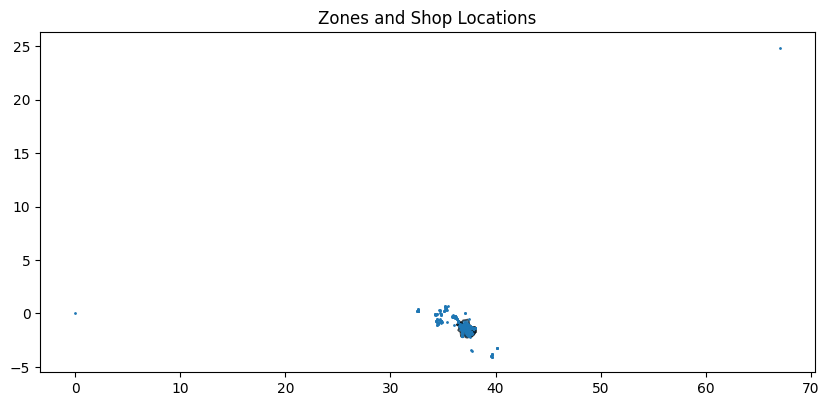

In [18]:

ax = zone_gdf.plot(
    figsize=(10,8),
    alpha=0.4,
    edgecolor='black'
)

shop_gdf.sample(
    min(2000,len(shop_gdf))
).plot(
    ax=ax,
    markersize=1
)

plt.title('Zones and Shop Locations')
plt.show()
